In [1]:
from typing import TypedDict, List, Any
from langgraph.graph import StateGraph, START, END
import hashlib
import sys
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["HF_HOME"] = r"D:\newthings\StructRAG\hf_cache"  # local folder, no symlink issues

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../")))

from docling.document_converter import DocumentConverter
from docling.chunking import HybridChunker
from sentence_transformers import SentenceTransformer
from qdrant_client.models import PointStruct
from db.qdrant_setup import setup_qdrant, COLLECTION_NAME 

d:\newthings\StructRAG\rag-env\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
d:\newthings\StructRAG\rag-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Models & clients ──────────────────────────────────────────────
embed_model = SentenceTransformer("all-MiniLM-L6-v2")
client = setup_qdrant(previous_client=globals().get("client"))

path_to_pdf = r"D:\newthings\StructRAG\centOSdepolyment.pdf"

# ── Docling: convert once up front ───────────────────────────────
converter = DocumentConverter()
docling_result = converter.convert(path_to_pdf)
docling_doc = docling_result.document         

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3735.52it/s]


pdf_collection created!


[INFO] 2026-05-14 10:24:00,146 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-14 10:24:00,158 [RapidOCR] download_file.py:60: File exists and is valid: D:\newthings\StructRAG\rag-env\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-05-14 10:24:00,160 [RapidOCR] main.py:57: Using D:\newthings\StructRAG\rag-env\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-05-14 10:24:00,371 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-14 10:24:00,376 [RapidOCR] download_file.py:60: File exists and is valid: D:\newthings\StructRAG\rag-env\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-05-14 10:24:00,379 [RapidOCR] main.py:57: Using D:\newthings\StructRAG\rag-env\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-05-14 10:24:00,484 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-05-14 10:24:00,496 [RapidOCR] download_file.p

In [3]:
# ── State ─────────────────────────────────────────────────────────
class PdfState(TypedDict):
    docling_doc: Any
    chunks: List[dict]
    embeddings: List[List[float]]


# ── Node 1: Chunk with Docling's HybridChunker ───────────────────
def chunk_node(state: PdfState):
    chunker = HybridChunker(
        tokenizer="BAAI/bge-small-en-v1.5",  # swap to your preferred tokenizer
        max_tokens=512,
        merge_peers=True,                     # merges small sibling chunks
    )

    raw_chunks = list(chunker.chunk(state["docling_doc"]))

    chunks = []
    for raw in raw_chunks:
        text = raw.text.strip()
        if not text:
            continue

        # Pull metadata Docling gives you for free
        meta = raw.meta
        headings = meta.headings if meta.headings else []
        page_start = None
        page_end = None

        # Page numbers live in the doc_items bounding boxes
        if hasattr(meta, "doc_items") and meta.doc_items:
            pages = []
            for item in meta.doc_items:
                if hasattr(item, "prov") and item.prov:
                    for prov in item.prov:
                        if hasattr(prov, "page_no"):
                            pages.append(prov.page_no)
            if pages:
                page_start = min(pages)
                page_end = max(pages)

        chunks.append({
            "id": hashlib.md5(text.encode()).hexdigest()[:8],
            "text": text,
            "heading": " > ".join(headings) if headings else None,
            "page_start": page_start,
            "page_end": page_end,
        })

    print(f"📄 Docling produced {len(chunks)} chunks")
    return {"chunks": chunks}


# ── Node 2: Embed ─────────────────────────────────────────────────
def embed_node(state: PdfState):
    chunks = state["chunks"]
    texts = [c["text"] for c in chunks]
    embeddings = embed_model.encode(texts)

    for i, chunk in enumerate(chunks):
        chunk["embedding"] = embeddings[i].tolist()

    return {
        "chunks": chunks,
        "embeddings": embeddings.tolist()
    }


# ── Node 3: Upsert to Qdrant ──────────────────────────────────────
def qdrant_node(state: PdfState):
    points = [
        PointStruct(
            id=i,
            vector=chunk["embedding"],
            payload={
                "text": chunk["text"],
                "heading": chunk.get("heading"),
                "page_start": chunk.get("page_start"),
                "page_end": chunk.get("page_end"),
            }
        )
        for i, chunk in enumerate(state["chunks"])
    ]

    client.upsert(collection_name=COLLECTION_NAME, points=points)  # ← always in sync
    return {"chunks": state["chunks"]}


📄 Docling produced 12 chunks
✅ Done! Inserted 12 chunks into Qdrant.


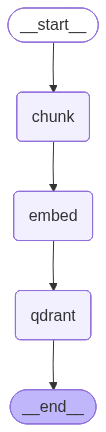

In [4]:
# ── Build & run graph ─────────────────────────────────────────────
graph = StateGraph(PdfState)

graph.add_node("chunk", chunk_node)
graph.add_node("embed", embed_node)
graph.add_node("qdrant", qdrant_node)

graph.add_edge(START, "chunk")
graph.add_edge("chunk", "embed")
graph.add_edge("embed", "qdrant")
graph.add_edge("qdrant", END)

app = graph.compile()

result = app.invoke({
    "docling_doc": docling_doc,
    "chunks": [],
    "embeddings": []
})

print(f"✅ Done! Inserted {len(result['chunks'])} chunks into Qdrant.")

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))